In [1]:
# Importing the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from plotly.offline import download_plotlyjs, init_notebook_mode

In [3]:
# Loading the data
test = pd.read_csv('aug_test.csv')
train = pd.read_csv('aug_train.csv')

In [5]:
# let’s have a quick look at some insights and check if we are having duplicated values
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  object 
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  last_new_job            18735 non-null  object 
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  float64
dtypes: float64(2), int64(2), object(10)
me

In [7]:
sim = train.duplicated() 
sim.sum()

0

In [9]:
missing_value = 100 * train.isnull().sum()/len(train)
missing_value = missing_value.reset_index()
missing_value.columns = ['variables','missing values in percentage']

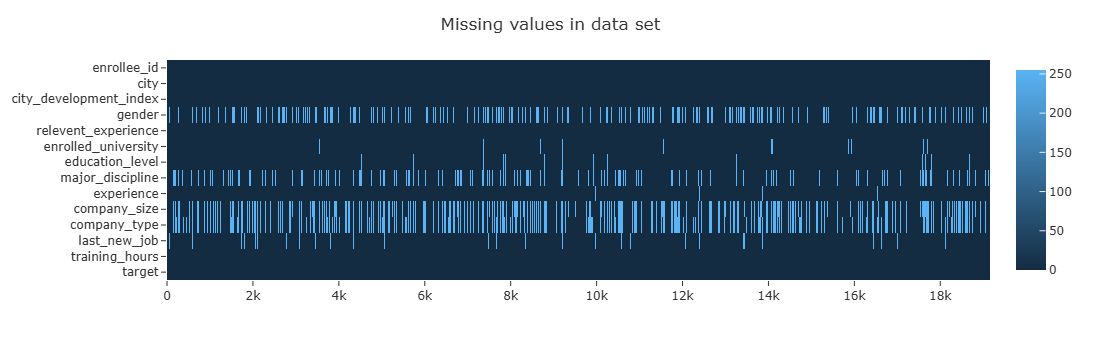

In [13]:
# heatmap
fig = px.imshow(train.isnull().T,template='ggplot2')
fig.update_layout(title='Missing values in data set')
fig.show()

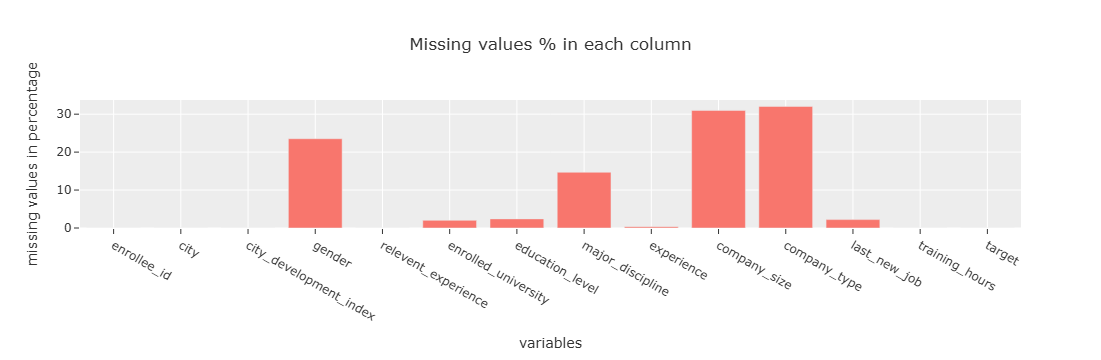

In [15]:
# barplot
fig = px.bar(missing_value, y='missing values in percentage',x='variables',title='Missing values % in each column',
             template='ggplot2');
fig.show()

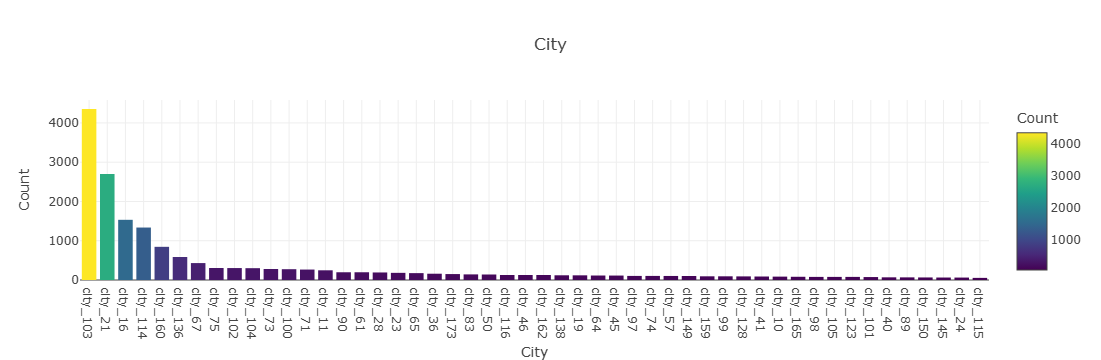

In [17]:
# As City Development Index is one of the most important features in the data, let’s start by analyzing it
plot_city = train['city'].value_counts()[0:50].reset_index()
plot_city.columns = ['City','Count']
px.bar(plot_city,x='City',y='Count',template='gridon',title='City',color='Count')

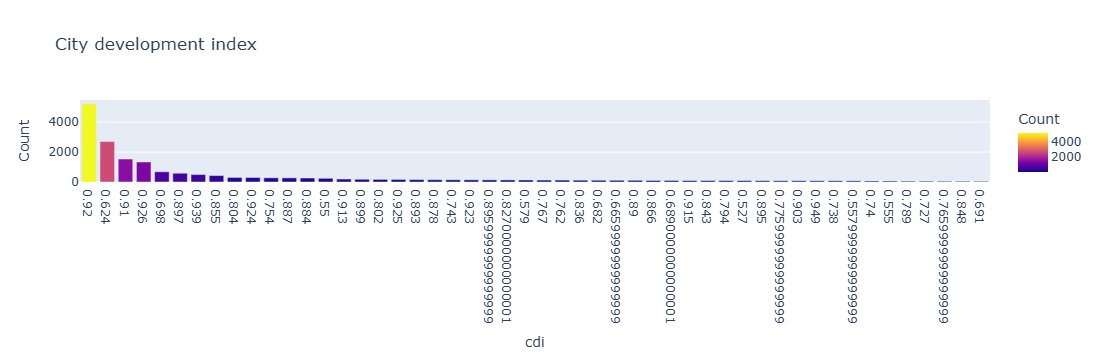

In [19]:
# The CDI crosses over the different clusters identified within the framework of urban indicators as it is based on five sub-indices namely, infrastructure, waste, health, education and city products
plot_cdi =train['city_development_index'].value_counts().reset_index()[0:50] 
plot_cdi.columns = ['cdi','Count']
plot_cdi['cdi'] = plot_cdi['cdi'].astype('str')
px.bar(plot_cdi,y="Count", x="cdi",color='Count',title='City development index')

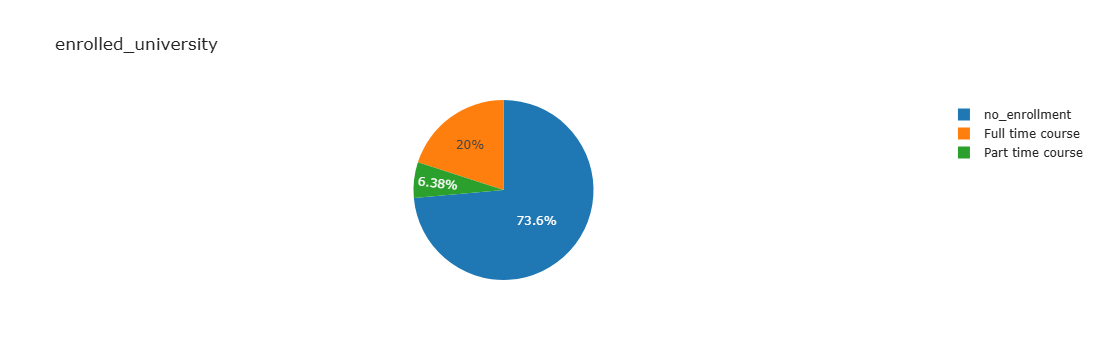

In [21]:
# Now let’s have a look at how many employees are coming for universities, full-time courses or part-time courses
plot_gender = train['enrolled_university'].value_counts().reset_index()
plot_gender.columns = ['enrolled_university','count']

px.pie(plot_gender,values='count',names='enrolled_university',template='simple_white',title='enrolled_university')

##### The above plot shows that more than 70 per cent of employees are coming without any course.

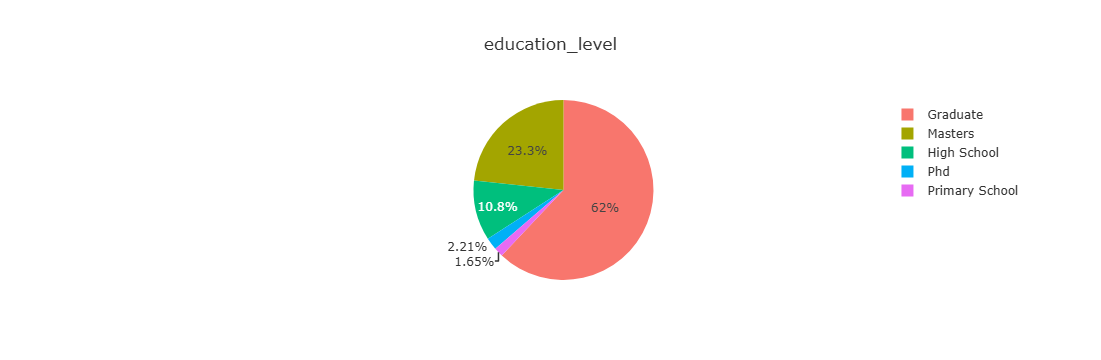

In [24]:
# Now let’s have a quick look at the distribution of education levels of the employees
plot_gender = train['education_level'].value_counts().reset_index()
plot_gender.columns = ['education_level','count']

px.pie(plot_gender,values='count',names='education_level',template='ggplot2',title='education_level')

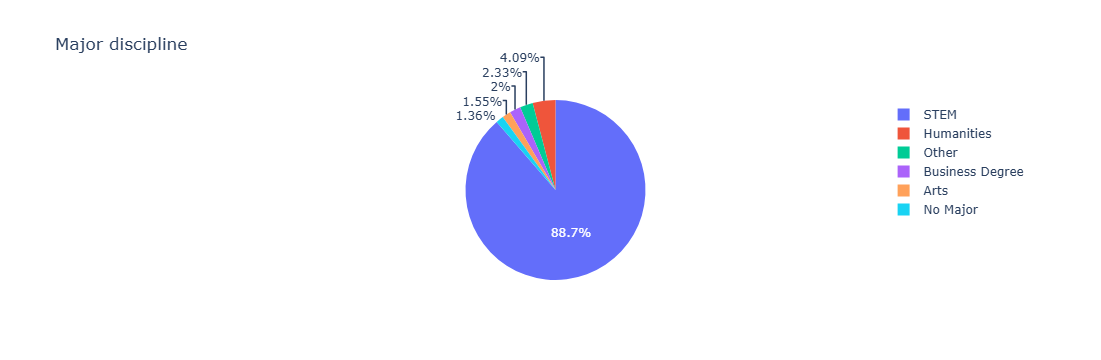

In [26]:
# Now the next task is to have a look at the major discipline of education of all the employees
plot_gender = train['major_discipline'].value_counts().reset_index()
plot_gender.columns = ['major_discipline','count']

px.pie(plot_gender,values='count',names='major_discipline',template='plotly',title='Major discipline')

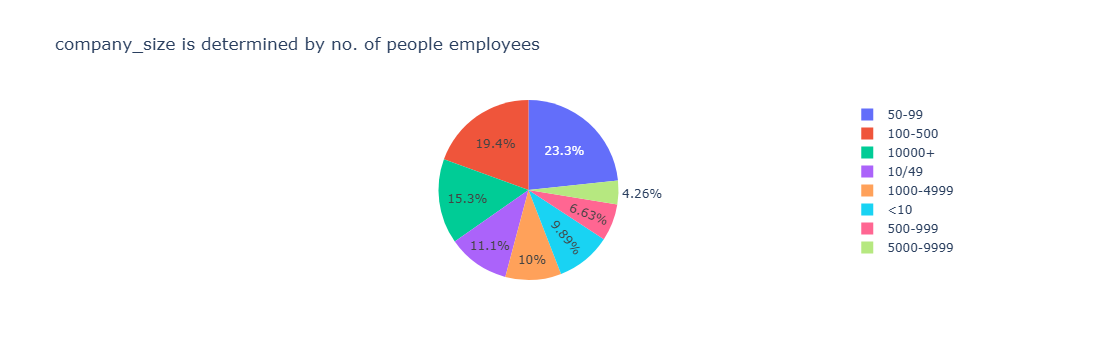

In [28]:
# At the end let’s analyze the distribution of the size of the company which is determined by the number of employees working in the company
plot_gender = train['company_size'].value_counts().reset_index()
plot_gender.columns = ['company_size','count']

px.pie(plot_gender,values='count',names='company_size',template='plotly_white',title='company_size is determined by no. of people employees')